In [30]:
import os
import sys
import calendar
import logging
import concurrent.futures
import geopandas as gpd
import xarray as xr
from retry import retry
import earthnet_minicuber as emc
from mypythonlib import myfunctions, phenolopy
import os
import xarray as xr
from tqdm import tqdm
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

def preprocess_and_reduce_minicube(ds, idx, output_folder):

    ds = ds.rename_dims({'lon': 'x', 'lat': 'y'})
    ds.rio.write_crs("epsg:4326", inplace=True)  # Set the coordinate reference system to EPSG:4326

    print(f"Remove clouds, shadows, and snow")
    # Calculate the fraction of 1 values in s2_mask for each time step
    mask_fraction = ds.s2_mask.where(ds.s2_mask == 0, 1).sum(dim=['x', 'y']) / (len(ds.x) * len(ds.y))

    # Filter the data to include only bands with names starting with 's2_B'
    filtered_data = ds[[b for b in ds.variables if 's2_B' in b]]

            # Mask out pixels where s2_mask is not equal to 0
    filtered_data = filtered_data.where(ds.s2_mask == 0)

    # Remove cirrus clouds from the entire dataset
    filtered_data = phenolopy.remove_cirrus_clouds(filtered_data)

    print(f"Remove outliers")
    # Remove outliers using a specified method
    remove_outliers = phenolopy.remove_outliers(filtered_data, method='median', user_factor=2, z_pval=0.07)

    print(f"Compute various vegetation indices")
    # Compute various vegetation indices and add them to the dataset
    print('NDVI')
    remove_outliers['ndvi'] = myfunctions.ndvi(remove_outliers)
    print('NBR')
    remove_outliers['nbr'] = myfunctions.nbr(remove_outliers)
    print('NDWI')
    remove_outliers['ndwi'] = myfunctions.ndwi(remove_outliers)
    print('NDRE')
    remove_outliers['ndre'] = myfunctions.ndre(remove_outliers)
    print('TCW')
    remove_outliers['tcw'] = myfunctions.tcw(remove_outliers)
    print('TCG')
    remove_outliers['tcg'] = myfunctions.tcg(remove_outliers)
    print('TCB')
    remove_outliers['tcb'] = myfunctions.tcb(remove_outliers)
    print('NDMI')
    remove_outliers['ndmi'] = myfunctions.ndmi(remove_outliers)
    print('NIRV')
    remove_outliers['nirv'] = myfunctions.nirv(remove_outliers)
    print('kNDVI')
    remove_outliers['kndvi'] = myfunctions.kndvi(remove_outliers, sigma=0.02)
    print('DRS/NDRS')
    remove_outliers['drs'] = myfunctions.drs(remove_outliers)
    remove_outliers['ndrs'] = myfunctions.ndrs(remove_outliers)
    print('kDRS/kNDRS')
    remove_outliers['kdrs'] = myfunctions.kdrs(remove_outliers, sigma=0.02)
    remove_outliers['kndrs'] = myfunctions.kndrs(remove_outliers)

    print(f"Sort temporal axis")
    remove_outliers = remove_outliers.sortby('time')

    print(f"Interpolate linearly over time")
    # Interpolate missing values linearly over time
    interpolated_data = remove_outliers.interpolate_na(dim='time', method='linear')

    print(f"Smooth data with Savitzky-Golay (window_length=15, polyorder=3)")
    # Smooth the data using the Savitzky-Golay filter
    smoothed_data = phenolopy.smooth(ds=interpolated_data, method='savitsky', window_length=15, polyorder=3)

    print(f"Calculate Anomaly for each variable")
    for var in smoothed_data.data_vars:
            print(var)
            smoothed_data[var+'_anom']     = smoothed_data[var].groupby('time.week')-smoothed_data[var].groupby('time.week').median()

    # Save the preprocessed data to a NetCDF file
    print(f"Compress data for saving to complevel=9")
    comp = dict(zlib=True, complevel=9)
    encoding = {var: comp for var in smoothed_data.data_vars}
    print(encoding)
    outputpath = os.path.join(output_folder, f"{idx}_merged_compressed.nc")
    smoothed_data.to_netcdf(outputpath, encoding=encoding)

    print(f"Saved to path = {outputpath}")


In [54]:
idx = 0
year = 2018
output_folder = f"/Net/Groups/BGI/scratch/fmueller/Data/s2_region8_nc_256px_vi/drought/{year}/{idx}/"
path = f"/Net/Groups/BGI/scratch/fmueller/Data/s2_region8_nc_256px_vi/drought/{year}/{idx}/{idx}_merged.nc"

In [46]:
dataset = xr.open_dataset(path)
print(f"Sort temporal axis")
ds = dataset.sortby('time')
ds = ds.rename_dims({'lon': 'x', 'lat': 'y'})
ds = ds.rio.write_crs("epsg:4326", inplace=True)
ds

Sort temporal axis


<xarray.Dataset> Size: 1GB
Dimensions:      (time: 190, y: 256, x: 256)
Coordinates:
    angle        <U6 24B ...
  * time         (time) datetime64[ns] 2kB 2015-10-03 2015-10-23 ... 2019-12-31
  * lon          (x) float64 2kB -86.04 -86.04 -86.04 ... -85.99 -85.99 -85.99
  * lat          (y) float64 2kB 33.35 33.35 33.35 33.35 ... 33.3 33.3 33.3 33.3
    spatial_ref  int64 8B 0
Dimensions without coordinates: y, x
Data variables: (12/15)
    s2_SCL       (time, y, x) float64 100MB ...
    s2_mask      (time, y, x) float64 100MB ...
    s2_avail     (time) uint8 190B ...
    s2_B01       (time, y, x) float64 100MB ...
    s2_B02       (time, y, x) float64 100MB ...
    s2_B03       (time, y, x) float64 100MB ...
    ...           ...
    s2_B07       (time, y, x) float64 100MB ...
    s2_B08       (time, y, x) float64 100MB ...
    s2_B8A       (time, y, x) float64 100MB ...
    s2_B09       (time, y, x) float64 100MB ...
    s2_B11       (time, y, x) float64 100MB ...
    s2_B12       (time, y, x) float64 100MB ...
Attributes:
    history:  Created on 2024-07-03 17:02:15.265431 with the earthnet-minicub...

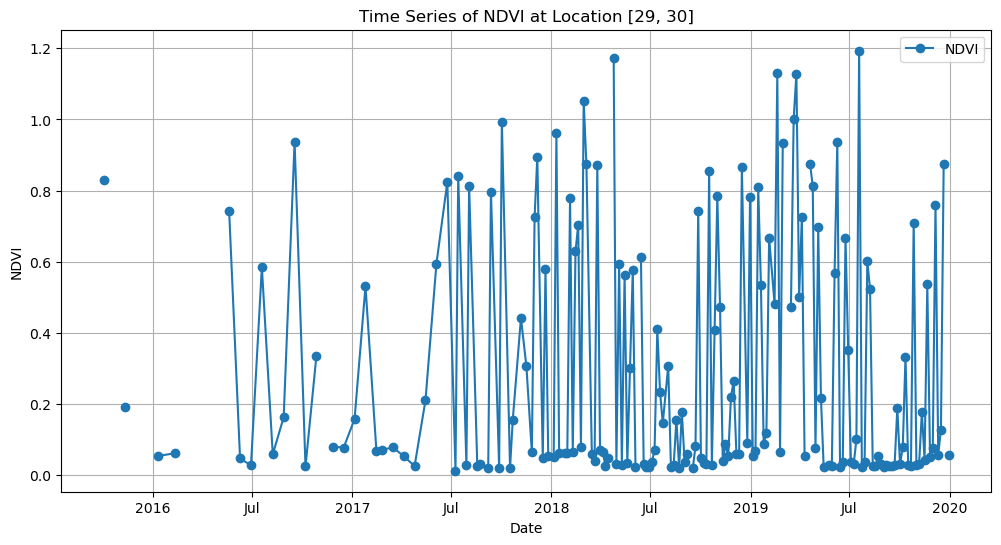

In [47]:
# Select the data at x=29 and y=30
ndvi_29_30 = ds.sel(x=29, y=200)['s2_B04']

# Plotting the time series
plt.figure(figsize=(12, 6))
ndvi_29_30.plot(label='NDVI', marker='o')

plt.xlabel('Date')
plt.ylabel('NDVI')
plt.title('Time Series of NDVI at Location [29, 30]')
plt.legend()
plt.grid(True)
plt.show()

In [48]:
ds = dataset.rename_dims({'lon': 'x', 'lat': 'y'})
ds.rio.write_crs("epsg:4326", inplace=True)  # Set the coordinate reference system to EPSG:4326

print(f"Remove clouds, shadows, and snow")
# Calculate the fraction of 1 values in s2_mask for each time step
mask_fraction = ds.s2_mask.where(ds.s2_mask == 0, 1).sum(dim=['x', 'y']) / (len(ds.x) * len(ds.y))

# Filter the data to include only bands with names starting with 's2_B'
filtered_data = ds[[b for b in ds.variables if 's2_B' in b]]

        # Mask out pixels where s2_mask is not equal to 0
filtered_data = filtered_data.where(ds.s2_mask == 0)
# Remove cirrus clouds from the entire dataset
filtered_data = phenolopy.remove_cirrus_clouds(filtered_data)

print(f"Remove outliers")
# Remove outliers using a specified method
remove_outliers = phenolopy.remove_outliers(filtered_data, method='median', user_factor=2, z_pval=0.07)

print(f"Compute various vegetation indices")
# Compute various vegetation indices and add them to the dataset
print('NDVI')
remove_outliers['ndvi'] = myfunctions.ndvi(remove_outliers)
print('NBR')
remove_outliers['nbr'] = myfunctions.nbr(remove_outliers)
print('NDWI')
remove_outliers['ndwi'] = myfunctions.ndwi(remove_outliers)
print('NDRE')
remove_outliers['ndre'] = myfunctions.ndre(remove_outliers)
print('TCW')
remove_outliers['tcw'] = myfunctions.tcw(remove_outliers)
print('TCG')
remove_outliers['tcg'] = myfunctions.tcg(remove_outliers)
print('TCB')
remove_outliers['tcb'] = myfunctions.tcb(remove_outliers)
print('NDMI')
remove_outliers['ndmi'] = myfunctions.ndmi(remove_outliers)
print('NIRV')
remove_outliers['nirv'] = myfunctions.nirv(remove_outliers)
print('kNDVI')
remove_outliers['kndvi'] = myfunctions.kndvi(remove_outliers, sigma=0.02)
print('DRS/NDRS')
remove_outliers['drs'] = myfunctions.drs(remove_outliers)
remove_outliers['ndrs'] = myfunctions.ndrs(remove_outliers)
print('kDRS/kNDRS')
remove_outliers['kdrs'] = myfunctions.kdrs(remove_outliers, sigma=0.02)
remove_outliers['kndrs'] = myfunctions.kndrs(remove_outliers)

print(f"Sort temporal axis")
remove_outliers = remove_outliers.sortby('time')
remove_outliers

Remove clouds, shadows, and snow
Remove outliers
Outlier removal method: median with a user factor of: 2


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/minicuber/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/minicuber/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/minicuber/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/minicuber/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/minicuber/lib/pytho

> Generated roll window size less than 3, setting to default (3).
> Warning: dataset contains nan values. You may want to interpolate next.
> Outlier removal successful.

Compute various vegetation indices
NDVI
NBR
NDWI
NDRE
TCW
TCG
TCB
NDMI
NIRV
kNDVI
DRS/NDRS
kDRS/kNDRS
Sort temporal axis


<xarray.Dataset> Size: 3GB
Dimensions:      (time: 190, y: 256, x: 256)
Coordinates:
    angle        <U6 24B 'Zenith'
  * time         (time) datetime64[ns] 2kB 2015-10-03 2015-10-23 ... 2019-12-31
  * lon          (x) float64 2kB -86.04 -86.04 -86.04 ... -85.99 -85.99 -85.99
  * lat          (y) float64 2kB 33.35 33.35 33.35 33.35 ... 33.3 33.3 33.3 33.3
    spatial_ref  int64 8B 0
Dimensions without coordinates: y, x
Data variables: (12/26)
    s2_B01       (time, y, x) float64 100MB nan nan nan ... 0.0001 0.0001
    s2_B02       (time, y, x) float64 100MB nan nan nan ... 0.005206 0.003295
    s2_B03       (time, y, x) float64 100MB nan nan nan ... 0.02352 0.02241
    s2_B04       (time, y, x) float64 100MB nan nan nan ... 0.01565 0.01381
    s2_B05       (time, y, x) float64 100MB nan nan nan ... 0.04562 0.03727
    s2_B06       (time, y, x) float64 100MB nan nan nan ... 0.1407 0.1226 0.1177
    ...           ...
    nirv         (time, y, x) float64 100MB nan nan nan ... 0.1407 0.1337 0.1317
    kndvi        (time, y, x) float64 100MB nan nan nan ... 0.5815 0.4393 0.2855
    drs          (time, y, x) float64 100MB nan nan nan ... 0.04587 0.03807
    ndrs         (time, y, x) float64 100MB nan nan nan ... 0.04199 0.03237
    kdrs         (time, y, x) float64 100MB nan nan nan ... 2.529 2.779 3.112
    kndrs        (time, y, x) float64 100MB nan nan nan ... 0.2646 0.3895 0.5558

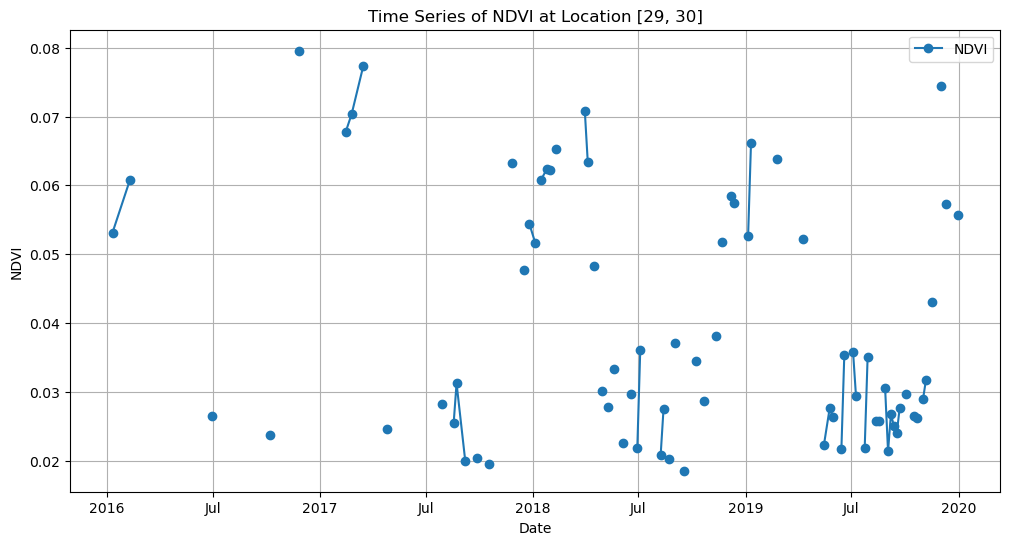

In [49]:
# Select the data at x=29 and y=30
ndvi_29_30 = remove_outliers.sel(x=29, y=200)['s2_B04']

# Plotting the time series
plt.figure(figsize=(12, 6))
ndvi_29_30.plot(label='NDVI', marker='o')

plt.xlabel('Date')
plt.ylabel('NDVI')
plt.title('Time Series of NDVI at Location [29, 30]')
plt.legend()
plt.grid(True)
plt.show()

In [50]:
print(f"Interpolate linearly over time")
# Interpolate missing values linearly over time
interpolated_data = remove_outliers.interpolate_na(dim='time', method='linear')

print(f"Smooth data with Savitzky-Golay (window_length=15, polyorder=3)")
# Smooth the data using the Savitzky-Golay filter
smoothed_data = phenolopy.smooth(ds=interpolated_data, method='savitsky', window_length=15, polyorder=3)
smoothed_data

Interpolate linearly over time


Smooth data with Savitzky-Golay (window_length=15, polyorder=3)
Smoothing method: savitsky with window length: 15, polyorder: 3  and mode: nearest.
> Warning: dataset contains nan values. You may want to interpolate next.
> Smoothing successful.



<xarray.Dataset> Size: 3GB
Dimensions:      (time: 190, x: 256, y: 256)
Coordinates:
    angle        <U6 24B 'Zenith'
  * time         (time) datetime64[ns] 2kB 2015-10-03 2015-10-23 ... 2019-12-31
  * lon          (x) float64 2kB -86.04 -86.04 -86.04 ... -85.99 -85.99 -85.99
  * lat          (y) float64 2kB 33.35 33.35 33.35 33.35 ... 33.3 33.3 33.3 33.3
    spatial_ref  int64 8B 0
Dimensions without coordinates: x, y
Data variables: (12/26)
    s2_B01       (time, y, x) float64 100MB nan nan nan ... 9.253e-05 9.253e-05
    s2_B02       (time, y, x) float64 100MB nan nan nan ... 0.005662 0.003588
    s2_B03       (time, y, x) float64 100MB nan nan nan ... 0.02367 0.02221
    s2_B04       (time, y, x) float64 100MB nan nan nan ... 0.0166 0.01471
    s2_B05       (time, y, x) float64 100MB nan nan nan ... 0.04618 0.03686
    s2_B06       (time, y, x) float64 100MB nan nan nan ... 0.1401 0.1203 0.1146
    ...           ...
    nirv         (time, y, x) float64 100MB nan nan nan ... 0.1382 0.1304 0.1269
    kndvi        (time, y, x) float64 100MB nan nan nan ... 0.5164 0.3856 0.2506
    drs          (time, y, x) float64 100MB nan nan nan ... 0.04522 0.03784
    ndrs         (time, y, x) float64 100MB nan nan nan ... 0.04119 0.03209
    kdrs         (time, y, x) float64 100MB nan nan nan ... 2.653 2.899 3.206
    kndrs        (time, y, x) float64 100MB nan nan nan ... 0.3265 0.4495 0.603

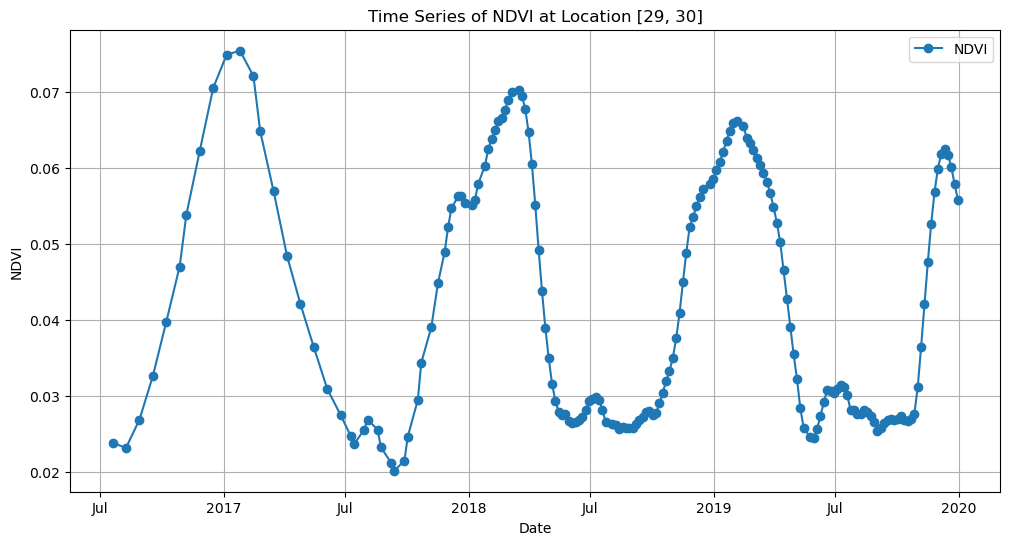

In [51]:
# Select the data at x=29 and y=30
ndvi_29_30 = smoothed_data.sel(x=29, y=200)['s2_B04']

# Plotting the time series
plt.figure(figsize=(12, 6))
ndvi_29_30.plot(label='NDVI', marker='o')

plt.xlabel('Date')
plt.ylabel('NDVI')
plt.title('Time Series of NDVI at Location [29, 30]')
plt.legend()
plt.grid(True)
plt.show()

In [52]:
print(f"Calculate Anomaly for each variable")
for var in smoothed_data.data_vars:
        print(var)
        smoothed_data[var+'_anom']     = smoothed_data[var].groupby('time.week')-smoothed_data[var].groupby('time.week').median()
        
smoothed_data

Calculate Anomaly for each variable
s2_B01


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/minicuber/lib/python3.10/site-packages/xarray/core/accessor_dt.py:441: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/minicuber/lib/python3.10/site-packages/xarray/core/accessor_dt.py:441: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(


s2_B02


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/minicuber/lib/python3.10/site-packages/xarray/core/accessor_dt.py:441: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/minicuber/lib/python3.10/site-packages/xarray/core/accessor_dt.py:441: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(


s2_B03


...

kdrs


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/minicuber/lib/python3.10/site-packages/xarray/core/accessor_dt.py:441: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/minicuber/lib/python3.10/site-packages/xarray/core/accessor_dt.py:441: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(


kndrs


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/minicuber/lib/python3.10/site-packages/xarray/core/accessor_dt.py:441: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/minicuber/lib/python3.10/site-packages/xarray/core/accessor_dt.py:441: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(


<xarray.Dataset> Size: 5GB
Dimensions:      (time: 190, x: 256, y: 256)
Coordinates:
    angle        <U6 24B 'Zenith'
  * time         (time) datetime64[ns] 2kB 2015-10-03 2015-10-23 ... 2019-12-31
  * lon          (x) float64 2kB -86.04 -86.04 -86.04 ... -85.99 -85.99 -85.99
  * lat          (y) float64 2kB 33.35 33.35 33.35 33.35 ... 33.3 33.3 33.3 33.3
    spatial_ref  int64 8B 0
    week         (time) int64 2kB 40 43 46 52 2 6 12 16 ... 48 49 50 51 51 52 1
Dimensions without coordinates: x, y
Data variables: (12/52)
    s2_B01       (time, y, x) float64 100MB nan nan nan ... 9.253e-05 9.253e-05
    s2_B02       (time, y, x) float64 100MB nan nan nan ... 0.005662 0.003588
    s2_B03       (time, y, x) float64 100MB nan nan nan ... 0.02367 0.02221
    s2_B04       (time, y, x) float64 100MB nan nan nan ... 0.0166 0.01471
    s2_B05       (time, y, x) float64 100MB nan nan nan ... 0.04618 0.03686
    s2_B06       (time, y, x) float64 100MB nan nan nan ... 0.1401 0.1203 0.1146
    ...           ...
    nirv_anom    (time, y, x) float64 100MB nan nan nan ... 0.00566 -0.009498
    kndvi_anom   (time, y, x) float64 100MB nan nan nan ... -0.09745 -0.05639
    drs_anom     (time, y, x) float64 100MB nan nan nan ... -0.01453 -0.01836
    ndrs_anom    (time, y, x) float64 100MB nan nan nan ... -0.01792 -0.02264
    kdrs_anom    (time, y, x) float64 100MB nan nan nan ... 0.1812 0.1439
    kndrs_anom   (time, y, x) float64 100MB nan nan nan ... 0.09059 0.07197

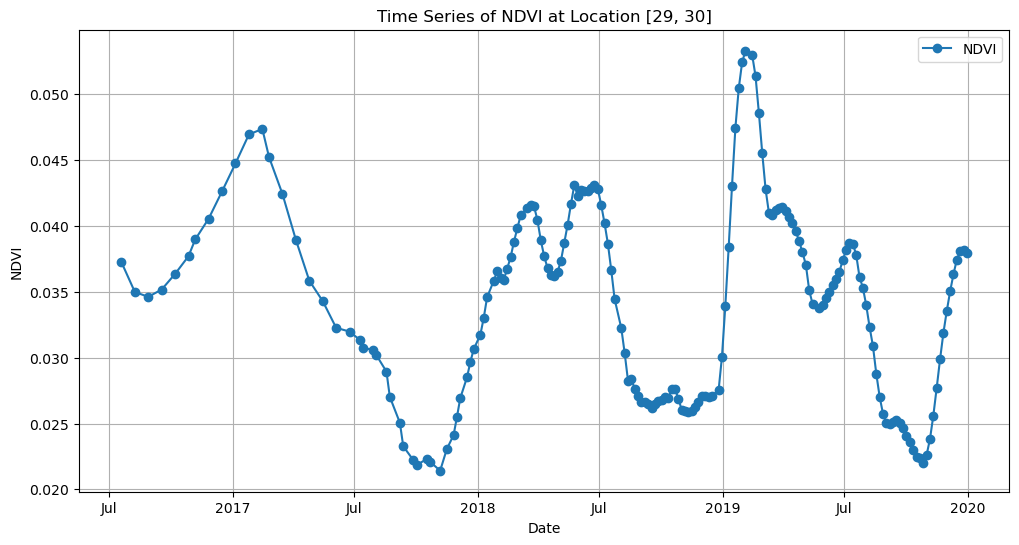

In [53]:
# Select the data at x=29 and y=30
ndvi_29_30 = smoothed_data.sel(x=2, y=30)['s2_B04']

# Plotting the time series
plt.figure(figsize=(12, 6))
ndvi_29_30.plot(label='NDVI', marker='o')

plt.xlabel('Date')
plt.ylabel('NDVI')
plt.title('Time Series of NDVI at Location [29, 30]')
plt.legend()
plt.grid(True)
plt.show()

In [55]:
# Save the preprocessed data to a NetCDF file
print(f"Compress data for saving to complevel=9")
comp = dict(zlib=True, complevel=9)
encoding = {var: comp for var in smoothed_data.data_vars}
print(encoding)
outputpath = os.path.join(output_folder, f"{idx}_merged_compressed.nc")
smoothed_data.to_netcdf(outputpath, encoding=encoding)

print(f"Saved to path = {outputpath}")

Compress data for saving to complevel=9
{'s2_B01': {'zlib': True, 'complevel': 9}, 's2_B02': {'zlib': True, 'complevel': 9}, 's2_B03': {'zlib': True, 'complevel': 9}, 's2_B04': {'zlib': True, 'complevel': 9}, 's2_B05': {'zlib': True, 'complevel': 9}, 's2_B06': {'zlib': True, 'complevel': 9}, 's2_B07': {'zlib': True, 'complevel': 9}, 's2_B08': {'zlib': True, 'complevel': 9}, 's2_B8A': {'zlib': True, 'complevel': 9}, 's2_B09': {'zlib': True, 'complevel': 9}, 's2_B11': {'zlib': True, 'complevel': 9}, 's2_B12': {'zlib': True, 'complevel': 9}, 'ndvi': {'zlib': True, 'complevel': 9}, 'nbr': {'zlib': True, 'complevel': 9}, 'ndwi': {'zlib': True, 'complevel': 9}, 'ndre': {'zlib': True, 'complevel': 9}, 'tcw': {'zlib': True, 'complevel': 9}, 'tcg': {'zlib': True, 'complevel': 9}, 'tcb': {'zlib': True, 'complevel': 9}, 'ndmi': {'zlib': True, 'complevel': 9}, 'nirv': {'zlib': True, 'complevel': 9}, 'kndvi': {'zlib': True, 'complevel': 9}, 'drs': {'zlib': True, 'complevel': 9}, 'ndrs': {'zlib': Tr